# Europe Electricity Load hourly 

## EDA - Enerdy Demand vs Time

* clean and preprocessing data
* check distribution and outliers
* add time features

### Load data

* from Kaggle
- load from the link
- download europe-electricity-load-hourly-20192025.csv
* save in /data/raw

In [3]:
import sys
import os

# Add the src directory to the system path to allow importing custom modules
sys.path.insert(0, os.path.abspath('../src'))

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import pandas as pd

from fetch_prepare_data import create_time_based_features

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import shutil
import os

dataset_link = "dsersun/europe-electricity-load-hourly-20192025"  # just the owner/dataset part
destination = "../data/raw"

cache_path = kagglehub.dataset_download(dataset_link)
#print(f"Downloaded to cache: {cache_path}")

os.makedirs(destination, exist_ok=True)

# Copy all files from cache to destination
for file in os.listdir(cache_path):
    shutil.copy(os.path.join(cache_path, file), destination)
    print(f"Copied: {file} → {destination}")

In [ ]:
import pandas as pd

# Load the dataset from downlowaded csv file from kaggle
file_path = "../data/raw/MHLV_2019_2025_combined.csv"
df_energy = pd.read_csv(file_path, parse_dates=['DateUTC', 'DateShort'])

### Check the structure, data types and values

In [ ]:
display(df_energy.head())
print(df_energy.info())
print(df_energy.describe())

## Data Cleaning and Preprocessing

* Dataset includes only two useful columns - DateUTC, Value
* remove the rest columns
* rename Value to EnergyDemand
* reduce the data to Germany (CountryCode=='DE') only

In [ ]:
df_energy = df_energy.drop(['DateShort', 'MeasureItem', 'TimeFrom', 'TimeTo', 'Cov_ratio', 'Value_ScaleTo100'], axis=1)
df_energy = df_energy.rename(columns={'Value': 'EnergyDemand'})
df_energy = df_energy[df_energy['CountryCode'] == 'DE']
df_energy = df_energy.drop('CountryCode', axis=1)


In [ ]:
df_energy['hour'] = df_energy['DateUTC'].dt.hour
df_energy['weekday'] = df_energy['DateUTC'].dt.dayofweek
df_energy['month'] = df_energy['DateUTC'].dt.month
df_energy['is_weekend'] = (df_energy['DateUTC'].dt.weekday >= 5).astype(int)

### Add holiday feature

* non-working days effect the energy consumption 
* create holiday feature 

In [ ]:
%pip install holidays

In [ ]:
# Shared calendar features: population-weighted public and school holidays
df_energy = create_time_based_features(
    df_energy,
    in_year=int(df_energy['DateUTC'].dt.year.max()),
    time_column='DateUTC',
)

In [ ]:
# add pandemic feature
pandemic_start = pd.to_datetime('2020-03-01')
pandemic_end = pd.to_datetime('2021-12-31')
df_energy['is_pandemic_time'] = df_energy['DateUTC'].apply(lambda x: 1 if (x >= pandemic_start) and (x <= pandemic_end) else 0)


In [ ]:
# save the cleaned dataset for future use
df_energy.to_csv("../data/energy_demand_de_2019_2025.csv", index=False)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd   

df_monthly = df_energy.set_index('DateUTC')['EnergyDemand'].resample('ME').mean().reset_index()

# Convert dates to float for regression
df_monthly['DateNum'] = mdates.date2num(df_monthly['DateUTC'])

fig, ax = plt.subplots(figsize=(10, 2))
sns.lineplot(data=df_monthly, x='DateUTC', y='EnergyDemand', ax=ax)
plt.title('Electricity Load in Germany (2019-01-01 - 2025-09-30) - Monthly Mean')

# add trend line
sns.regplot(data=df_monthly, x='DateNum', y='EnergyDemand',
            scatter=False, color='orange', label='Trend Line', ax=ax)

#plt.ylim(0, df_monthly['EnergyDemand'].max() * 1.1)
plt.xlabel('Year')
plt.ylabel('Load (MW)')
plt.show()

### Time series decomposition

* additive model - seasonal values and redisual independent on trend
* in case of linear trend

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_monthly = df_energy_de.set_index('DateUTC')['EnergyDemand'].resample('ME').mean().reset_index()
df_monthly.set_index('DateUTC', inplace=True)
# Convert dates to float for regression
df_monthly['DateNum'] = mdates.date2num(df_monthly.index)

slope, intercept = np.polyfit(df_monthly['DateNum'], df_monthly['EnergyDemand'], 1) # estimate line coefficient
trend = df_monthly['DateNum'] * slope + intercept # linear trend
detrended = df_monthly['EnergyDemand'] - trend # remove the trend

plt.figure(figsize=(10, 5))
plt.plot(df_monthly['EnergyDemand'], label='Original')
plt.plot(trend, label='Trend')
plt.plot(detrended, label='Detrended')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Energy Demand (MW)')
plt.show()

### Time series decomposition - additive vs multiplicative

* clear seasonal/yearly pattern
* trend - long-term development 

In [ ]:
# decompose seasonality using seasonal_decompose
from statsmodels.tsa.seasonal import seasonal_decompose     
#df_monthly.set_index('DateUTC', inplace=True)
decomposition = seasonal_decompose(df_monthly['EnergyDemand'], model='additive', period=12) # monthly data, so period is 12 months
fig = decomposition.plot();  # use ; to avoid doubled plot. the returned figure is already plotted by the function, so we just suppress the output to avoid a second empty plot.
fig.suptitle('Additive Decomposition', fontsize=14, y=1.05)
plt.show()

In [ ]:
# decompose seasonality using seasonal_decompose with multiplicative model
from statsmodels.tsa.seasonal import seasonal_decompose     
#df_monthly.set_index('DateUTC', inplace=True)
decomposition = seasonal_decompose(df_monthly['EnergyDemand'], model='multiplicative', period=12) # monthly data, so period is 12 months
decomposition.plot();  # use ; to avoid doubled plot. the returned figure is already plotted by the function, so we just suppress the output to avoid a second empty plot.

### Distribution on different time features

* is_weekend, is_holiday, is_bridge_day distribution
* Weekday, week, month distribution

Database ready: c:\Data\Stackfuel-Unterricht\Portfolio\Europe_Electricity_Load\workspace_energy_demand\db\energy_demand.db

Current data status:
  energy         :  64672 rows | max: 2026-05-25T23:00:00+0200 | up-to-date: True
  weather        :  64825 rows | max: 2026-05-26T01:00:00+0200 | up-to-date: True

[Energy] Up to date — nothing to do.

[Weather] Up to date — nothing to do.

Done.
  energy_demand : 64672 rows | max: 2026-05-25T23:00:00+0200
  weather       : 64825 rows | max: 2026-05-26T01:00:00+0200


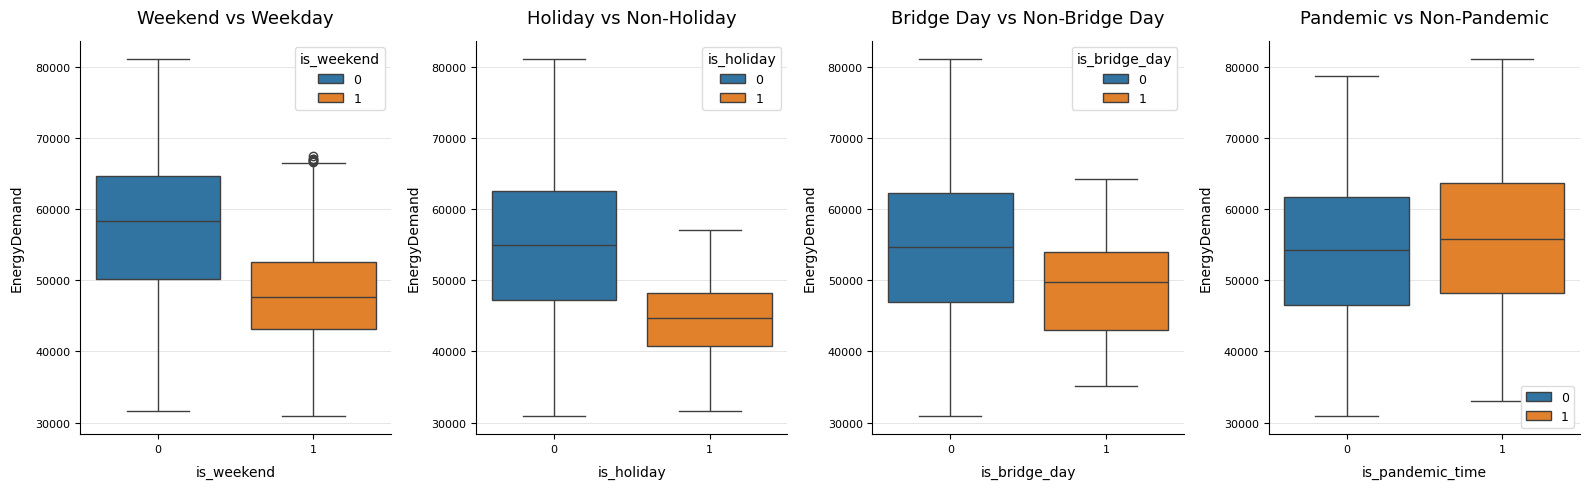

In [13]:
# plot weekend, holiday effects
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#df_energy_de = pd.read_csv("../data/processed/energy_demand_de_2019_2025.csv", parse_dates=['DateUTC'])

from etl import update_database, get_connection, load_combined_data

# Ensure the database is up to date — no-op if already current
update_database()

# Load the pre-joined, feature-engineered dataset from the DB view
conn = get_connection()
df_raw = load_combined_data(conn)
conn.close()

# Drop non-predictive columns; rename target to match existing pipeline conventions
df_for_modeling = (
    df_raw
    .drop(columns=['smard_forecast_mwh', 'data_source'], errors='ignore')
    .rename(columns={'energy_demand_mwh': 'EnergyDemand'})
    .dropna()
    .reset_index(drop=True)
)

df_energy_de = df_for_modeling.copy()  # for EDA, we can work with the same dataset

# boxplot for weekend, holiday effects
plt.figure(figsize=(16, 5))
plt.subplot(1, 4, 1)
sns.boxplot(x='is_weekend', y='EnergyDemand', hue='is_weekend', data=df_energy_de)
plt.title('Weekend vs Weekday')
plt.subplot(1, 4, 2)
sns.boxplot(x='is_holiday', y='EnergyDemand', hue='is_holiday', data=df_energy_de)
plt.title('Holiday vs Non-Holiday')
plt.subplot(1, 4, 3)
sns.boxplot(x='is_bridge_day', y='EnergyDemand', hue='is_bridge_day', data=df_energy_de)
plt.title('Bridge Day vs Non-Bridge Day')
plt.subplot(1, 4, 4)
sns.boxplot(x='is_pandemic_time', y='EnergyDemand', hue='is_pandemic_time', data=df_energy_de)
plt.title('Pandemic vs Non-Pandemic')
plt.gca().legend(loc='lower right')

plt.tight_layout()
plt.show()



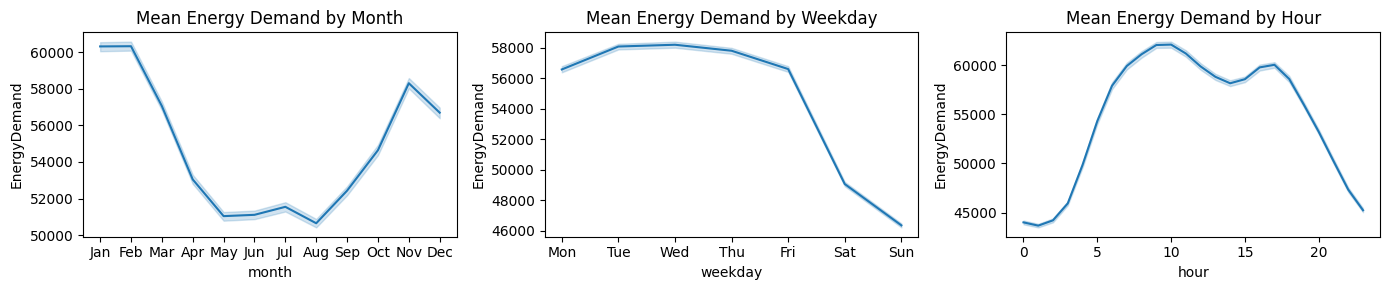

In [ ]:
# plot mean energy demand by month, weekday, hour
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#df_energy_de = pd.read_csv("../data/processed/energy_demand_de_2019_2025.csv", parse_dates=['DateUTC'])

plt.figure(figsize=(14, 3))
# rename x-axis labels for better readability
df_energy_de['month'] = df_energy_de['month'].map({1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'})
df_energy_de['weekday'] = df_energy_de['weekday'].map({0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'})  
# sort the weekday order
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_energy_de['weekday'] = pd.Categorical(df_energy_de['weekday'], categories=weekday_order, ordered=True) 

plt.subplot(1, 3, 1)
sns.lineplot(x='month', y='EnergyDemand', data=df_energy_de)
plt.title('Mean Energy Demand by Month')    
plt.subplot(1, 3, 2)
sns.lineplot(x='weekday', y='EnergyDemand', data=df_energy_de)
plt.title('Mean Energy Demand by Weekday')
plt.subplot(1, 3, 3)
sns.lineplot(x='hour', y='EnergyDemand', data=df_energy_de)
plt.title('Mean Energy Demand by Hour')
plt.tight_layout()
plt.show()